# Interactions Data Analysis

In [1]:
import os
import polars as pl

In [2]:
script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..', '..')
data_filename = 'interactions_processed_data.parquet'
data_path = os.path.join(project_path, 'data', 'interactions', 'processed_data', data_filename)

In [3]:
interactions_df = pl.read_parquet(data_path)

In [8]:
interactions_df

id,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,i64,i64,bool,bool,bool,cat,f64,str,bool
"""RamiroMaeztu-8pr""",0,5,true,false,true,"""Low""",null,null,false
"""RamiroMaeztu-0o0""",0,5,true,false,true,"""Low""",null,null,false
"""RamiroMaeztu-bzv""",0,5,true,false,true,"""Low""",null,null,false
"""RamiroMaeztu-z2k""",1,0,null,true,false,"""Lower_Intermediate""",1.0,"""Low""",false
"""RamiroMaeztu-2rr""",0,5,true,false,true,"""Low""",null,null,false
…,…,…,…,…,…,…,…,…,…
"""Laguna-9wq""",0,5,true,false,true,"""Low""",null,null,false
"""Laguna-c6j""",0,5,true,false,true,"""Low""",null,null,false
"""Laguna-6m6""",0,5,true,false,true,"""Low""",null,null,false


In [5]:
interactions_df['WSDI_cat'].value_counts()

WSDI_cat,count
str,u32
"""Superficial""",20
"""Deep""",3
"""Low_Intermediate""",22
"""High_Intermediate""",15
"""Not_Relevant""",3
null,30


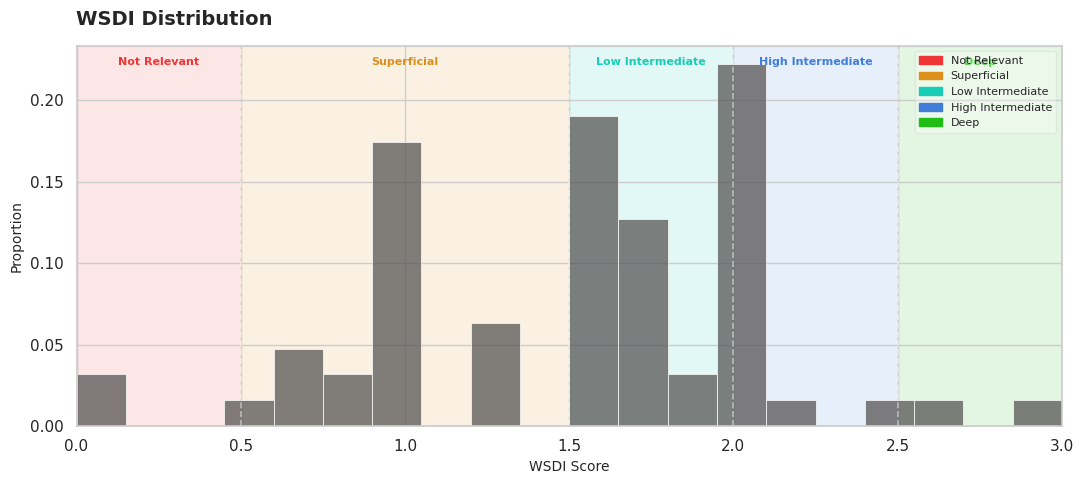

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Category config ---
categories = [
    {"label": "Not Relevant",       "range": (0,   0.5),  "color": "#EF3636"},
    {"label": "Superficial",        "range": (0.5, 1.5),  "color": "#DD8F1A"},
    {"label": "Low Intermediate",   "range": (1.5, 2.0),  "color": "#17CDB5"},
    {"label": "High Intermediate",  "range": (2.0, 2.5),  "color": "#417EDA"},
    {"label": "Deep",               "range": (2.5, 3.0),  "color": "#20BD15"},
]

# --- Style ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 5))

# --- Histogram ---
sns.histplot(
    data=interactions_df,
    x="WSDI",
    bins=20,
    color="#575555",
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
    stat='proportion'
)

# --- Colored background regions ---
for cat in categories:
    ax.axvspan(cat["range"][0], cat["range"][1], alpha=0.12, color=cat["color"], zorder=0)

# --- Boundary lines ---
for cat in categories[1:]:  # skip first boundary (0)
    x = cat["range"][0]
    ax.axvline(x=x, color="white", linewidth=1.2, linestyle="--", alpha=0.5)

# --- Category labels at top ---
for cat in categories:
    x_mid = (cat["range"][0] + cat["range"][1]) / 2
    ax.text(x_mid, ax.get_ylim()[1] * 0.97, cat["label"],
            color=cat["color"], fontsize=8, fontweight="bold",
            ha="center", va="top", alpha=1)

# --- Legend ---
patches = [mpatches.Patch(color=c["color"], label=c["label"]) for c in categories]
ax.legend(handles=patches, fontsize=8, framealpha=0.3, loc="upper right")

# --- Style ---
ax.set_title("WSDI Distribution", fontsize=14, fontweight="bold", loc="left", pad=15)
ax.set_xlabel("WSDI Score", fontsize=10)
ax.set_ylabel("Proportion", fontsize=10)
ax.set_xlim(0, 3)
ax.set_xticks([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0])

plt.tight_layout()
plt.show()

In [7]:
interactions_df.group_by(['high_quality_use', 'high_freq_use']).len()

high_quality_use,high_freq_use,len
bool,bool,u32
false,false,51
true,false,12
true,true,6
false,true,24


id,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,WSDI,WSDI_cat,high_quality_use,high_freq_use,chat_freq_use
str,i64,i64,bool,bool,bool,f64,str,bool,bool,cat
"""RamiroMaeztu-8pr""",0,5,true,false,true,null,null,false,false,"""Superficial"""
"""RamiroMaeztu-0o0""",0,5,true,false,true,null,null,false,false,"""Superficial"""
"""RamiroMaeztu-bzv""",0,5,true,false,true,null,null,false,false,"""Superficial"""
"""RamiroMaeztu-z2k""",1,0,null,true,false,1.0,"""Superficial""",false,false,"""Lower_Intermediate"""
"""RamiroMaeztu-2rr""",0,5,true,false,true,null,null,false,false,"""Superficial"""
…,…,…,…,…,…,…,…,…,…,…
"""Laguna-9wq""",0,5,true,false,true,null,null,false,false,"""Superficial"""
"""Laguna-c6j""",0,5,true,false,true,null,null,false,false,"""Superficial"""
"""Laguna-6m6""",0,5,true,false,true,null,null,false,false,"""Superficial"""


In [ ]:
interactions_df.group_by(['WSDI_cat', 'high_freq_use']).len()

In [ ]:
interactions_df['chat_interactions_counts'].sum()

233

In [ ]:
interactions_df.filter(pl.col('chat_interactions_counts') > 0)

id,chat_interactions_counts
str,i64
"""RamiroMaeztu-z2k""",1
"""RamiroMaeztu-qr3""",1
"""RamiroMaeztu-pu9""",8
"""RamiroMaeztu-31d""",6
"""RamiroMaeztu-ks0""",2
…,…
"""Laguna-zfa""",2
"""Laguna-4kk""",4
"""Laguna-ioy""",4


In [ ]:
len(interactions_df.filter(pl.col('chat_interactions_counts') == 0)) / len(interactions_df)

0.3225806451612903

In [ ]:
interactions_df.filter(pl.col('evaluation_answers_counts') == 0)

id,chat_interactions_counts,evaluation_answers_counts,evaluation_pass
str,i64,i64,bool
"""RamiroMaeztu-z2k""",1,0,null
"""RamiroMaeztu-qf6""",3,0,null
"""RamiroMaeztu-04b""",0,0,null
"""JesusMaria-iff""",0,0,null
"""JesusMaria-am7""",4,0,null
"""JesusMaria-4e6""",1,0,null
"""JoseGarciaNieto-9ba""",4,0,null


In [ ]:
interactions_df.filter((pl.col('evaluation_answers_counts') < 5) & (pl.col('evaluation_answers_counts') > 0))

id,chat_interactions_counts,evaluation_answers_counts,evaluation_pass
str,i64,i64,bool


In [ ]:
interactions_df.filter((pl.col('chat_interactions_counts') == 0) & (pl.col('evaluation_answers_counts') == 0))

id,chat_interactions_counts,evaluation_answers_counts,evaluation_pass
str,i64,i64,bool
"""RamiroMaeztu-04b""",0,0,null
"""JesusMaria-iff""",0,0,null


In [ ]:
interactions_df['evaluation_pass'].value_counts()

evaluation_pass,count
bool,u32
null,7
false,42
true,44


----